In [4]:
# ----------------------------------------------
# 1. Imports & Configuration
# ----------------------------------------------
# --------------------------------------------------
# 1. Imports and Data Load
# --------------------------------------------------
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [5]:
# Load dataset
df = pd.read_csv(r"C:\Users\nunna\Downloads\archive\heart_disease_uci.csv")


In [6]:
# Filter Cleveland data
cleveland_df = df[df['dataset'] == 'Cleveland'].copy()

cleveland_df.drop(columns=['dataset'], inplace=True)


Missing Values:
 slope    1
ca       5
thal     3
dtype: int64


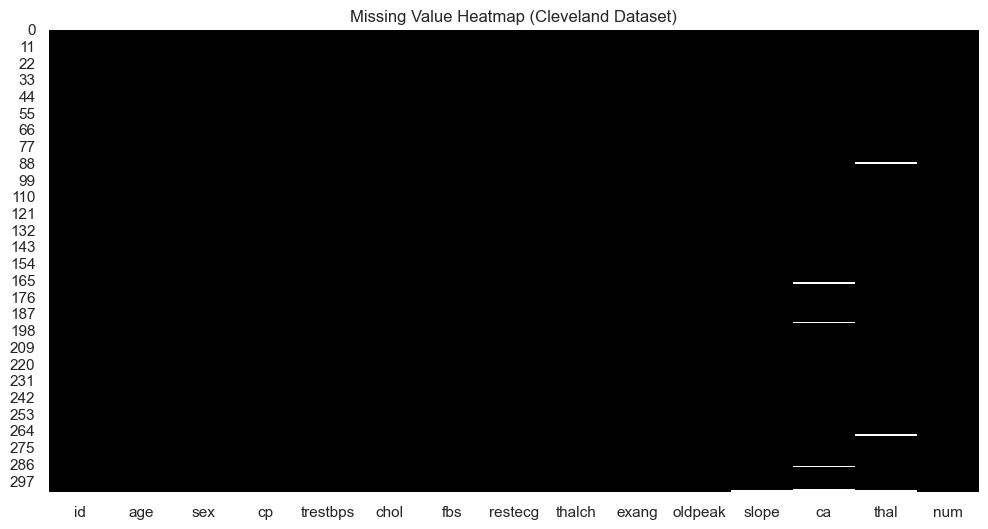

In [7]:
# --------------------------------------------------
# 2. Handle Missing Values
# --------------------------------------------------
print("Missing Values:\n", cleveland_df.isnull().sum()[cleveland_df.isnull().sum() > 0])

plt.figure(figsize=(12, 6))
sns.heatmap(cleveland_df.isnull(), cbar=False, cmap='bone')
plt.title("Missing Value Heatmap (Cleveland Dataset)")
plt.show()

In [8]:
# Impute missing values for numeric and categorical separately
numeric_cols = cleveland_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = cleveland_df.select_dtypes(include=['object']).columns

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

cleveland_df[numeric_cols] = num_imputer.fit_transform(cleveland_df[numeric_cols])
cleveland_df[categorical_cols] = cat_imputer.fit_transform(cleveland_df[categorical_cols])


In [9]:
# Label encode object columns
le = LabelEncoder()
for col in categorical_cols:
    cleveland_df[col] = le.fit_transform(cleveland_df[col])


In [10]:
# Convert target to binary (0 = no disease, 1 = has disease)
cleveland_df['num'] = cleveland_df['num'].apply(lambda x: 1 if x > 0 else 0)


In [11]:
# --------------------------------------------------
# 3. EDA Visualizations
# --------------------------------------------------
print("\n--- Dataset Info ---")
print(cleveland_df.info())
print("\n--- Summary Statistics ---")
print(cleveland_df.describe())



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 304 entries, 0 to 303
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        304 non-null    float64
 1   age       304 non-null    float64
 2   sex       304 non-null    int64  
 3   cp        304 non-null    int64  
 4   trestbps  304 non-null    float64
 5   chol      304 non-null    float64
 6   fbs       304 non-null    int64  
 7   restecg   304 non-null    int64  
 8   thalch    304 non-null    float64
 9   exang     304 non-null    int64  
 10  oldpeak   304 non-null    float64
 11  slope     304 non-null    int64  
 12  ca        304 non-null    float64
 13  thal      304 non-null    int64  
 14  num       304 non-null    int64  
dtypes: float64(7), int64(8)
memory usage: 38.0 KB
None

--- Summary Statistics ---
              id         age         sex          cp    trestbps        chol  \
count  304.00000  304.000000  304.000000  304.00000

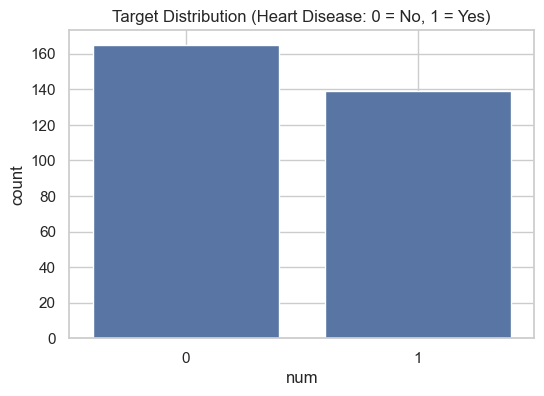

In [11]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='num', data=cleveland_df)
plt.title("Target Distribution (Heart Disease: 0 = No, 1 = Yes)")
plt.grid(True)
plt.show()

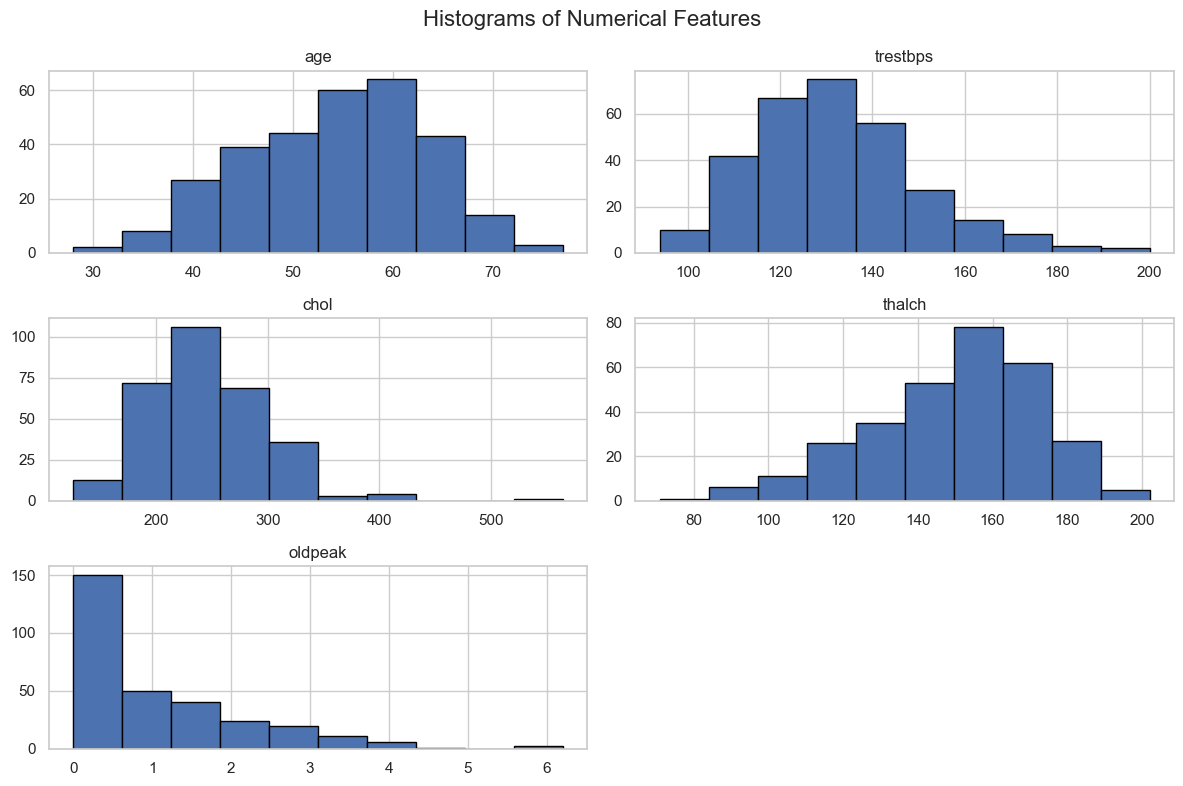

In [12]:
# Numerical histograms
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
cleveland_df[num_cols].hist(figsize=(12, 8), edgecolor='black')
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()


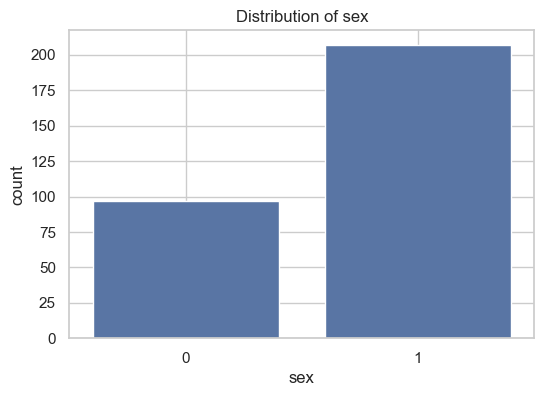

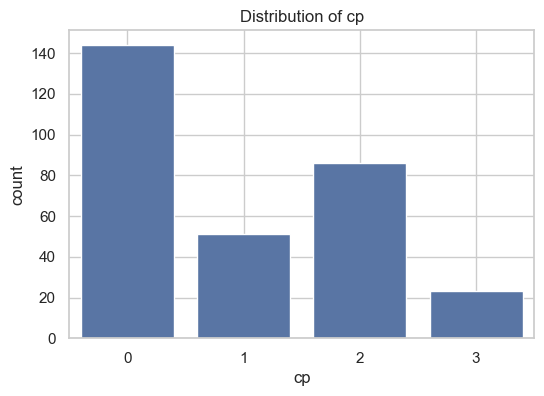

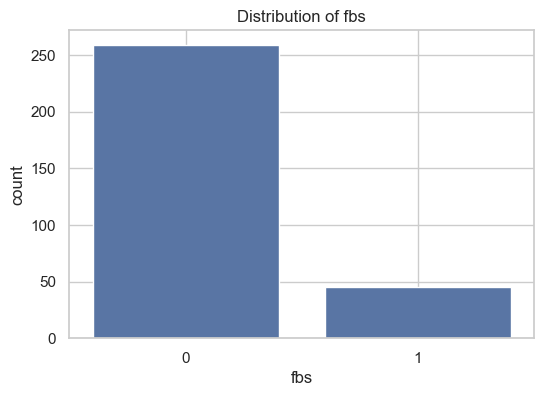

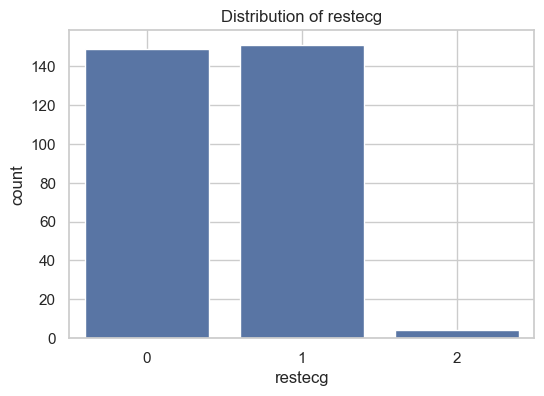

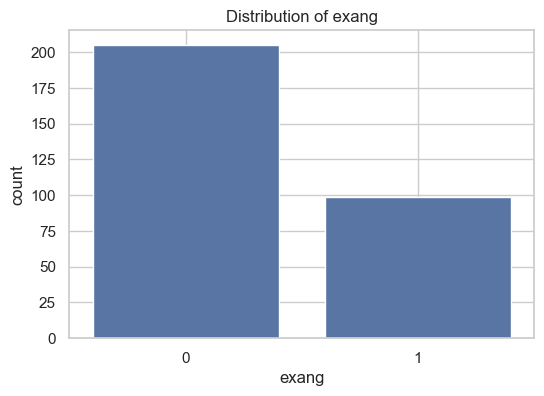

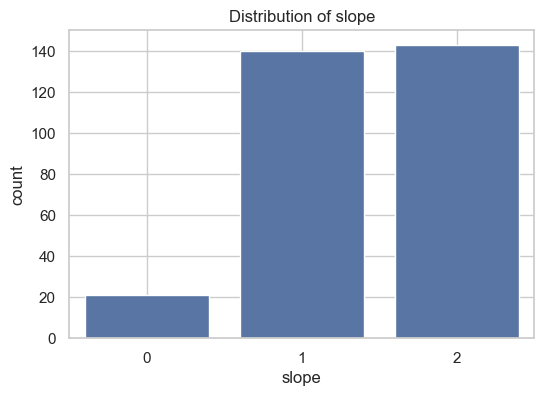

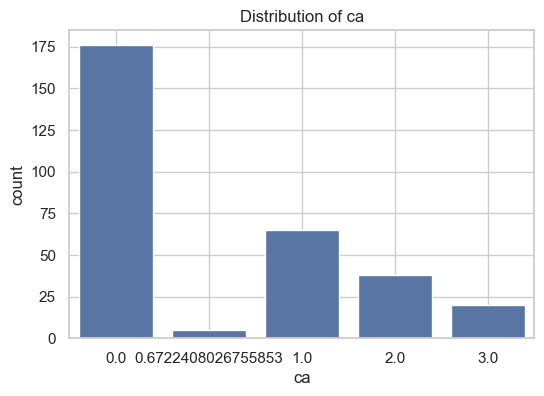

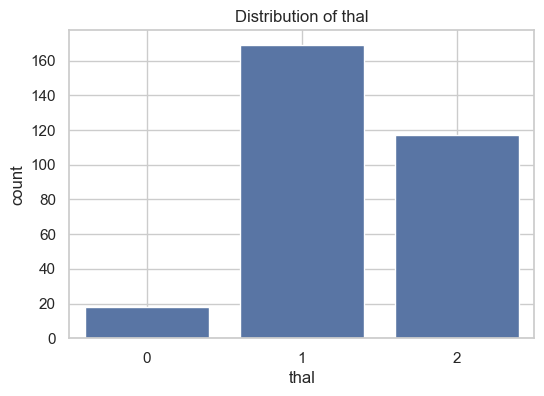

In [12]:
# Categorical plots
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=cleveland_df)
    plt.title(f"Distribution of {col}")
    plt.grid(True)
    plt.show()

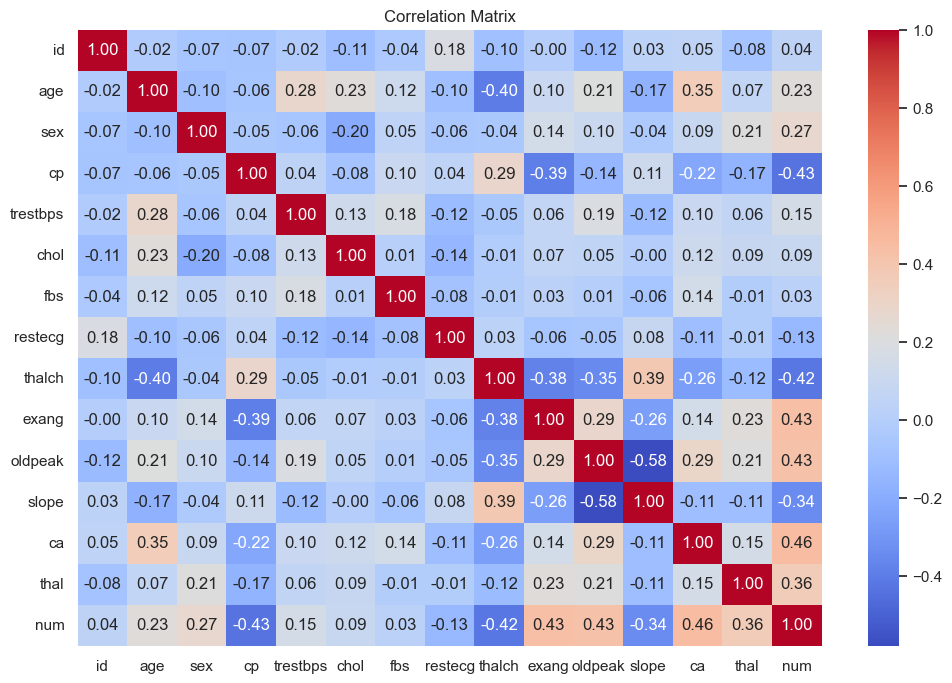

In [14]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cleveland_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [13]:

# 4. Scaling
# --------------------------------------------------
X_raw = cleveland_df.drop('num', axis=1)
y = cleveland_df['num']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)



--- Chi-Squared Feature Scores ---
     Feature  Chi2 Score
8     thalch  187.312511
12        ca   81.346003
10   oldpeak   71.515012
3         cp   62.898808
9      exang   38.444902
0         id   28.686995
5       chol   27.672501
1        age   24.363609
4   trestbps   16.177144
13      thal   10.068871
11     slope    9.554891
2        sex    7.290018
7    restecg    2.901832
6        fbs    0.181662

Top 10 selected features: ['thalch', 'ca', 'oldpeak', 'cp', 'exang', 'id', 'chol', 'age', 'trestbps', 'thal']


C:\Users\nunna\AppData\Local\Temp\ipykernel_23216\2600557727.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chi2_scores.head(10), x='Chi2 Score', y='Feature', palette='viridis')


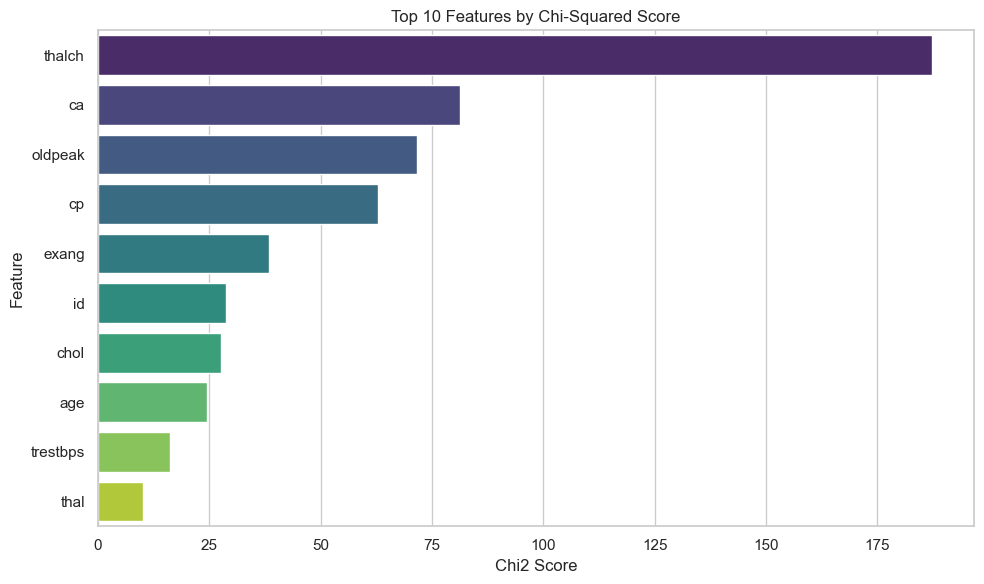

In [15]:
# --------------------------------------------------

# 5. Feature Selection (Chi-Squared)
# --------------------------------------------------
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_raw, y)

# Chi2 scores
chi2_scores = pd.DataFrame({
    'Feature': X_raw.columns,
    'Chi2 Score': chi2_selector.scores_
}).sort_values(by='Chi2 Score', ascending=False)

print("\n--- Chi-Squared Feature Scores ---")
print(chi2_scores)

# Optional: select top K features
top_k = 10
selected_features = chi2_scores['Feature'].head(top_k).tolist()
print(f"\nTop {top_k} selected features: {selected_features}")

# Select top features from scaled data
X_selected = pd.DataFrame(X_scaled, columns=X_raw.columns)[selected_features]

# Plot top 10
plt.figure(figsize=(10, 6))
sns.barplot(data=chi2_scores.head(10), x='Chi2 Score', y='Feature', palette='viridis')
plt.title("Top 10 Features by Chi-Squared Score")
plt.tight_layout()
plt.show()


In [17]:
# --------------------------------------------------
# 6. Model Training & Evaluation
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc = roc_auc_score(y_test, y_proba)

    results.append([name, acc, prec, rec, f1, roc])


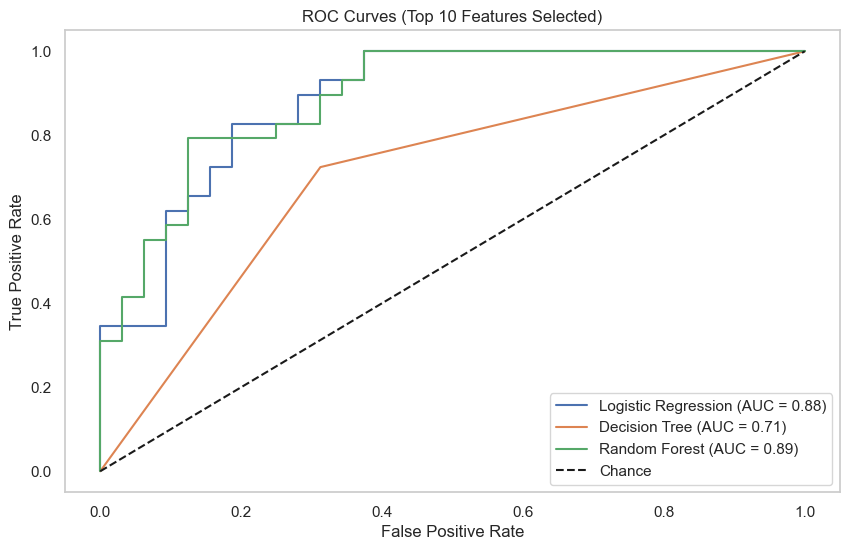

In [18]:
# --------------------------------------------------
# 7. ROC Curves
# --------------------------------------------------
plt.figure(figsize=(10, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Top 10 Features Selected)')
plt.legend()
plt.grid()
plt.show()

In [19]:
# --------------------------------------------------
# 8. Summary Table
# --------------------------------------------------
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'])
print("\n--- Model Evaluation Summary ---")
print(results_df)


--- Model Evaluation Summary ---
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.803279   0.805218  0.803279  0.803384  0.883621
1        Decision Tree  0.704918   0.706751  0.704918  0.705077  0.705819
2        Random Forest  0.819672   0.819725  0.819672  0.819477  0.891164
